In [102]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit
import pprint
from pathlib import Path
import sys
import os
pd.set_option("display.max_columns", None)

In [103]:
### Changing to parent directory
current_file_path = Path("").resolve()
grandparent_dir = current_file_path.parent.parent
# Append this directory to the system path
sys.path.append(str(grandparent_dir))

In [104]:
filepath = os.path.join(grandparent_dir,"ProcessedData/preprocessed_data_final.csv")

### 1. Data

In [105]:
f_val =  96485 / (8.314 * 298)

In [106]:
df = pd.read_csv(filepath)
cols = ["Freq","Modulation","File Number","VHr1","VHi1","IHr1","IHi1","IHr2","IHi2"]
orders = ["2nd","4th","6th"]
A_cols = []
for order in orders:
    A_cols.append(f"Re{{A1}}, {order} order")
    A_cols.append(f"Im{{A1}}, {order} order")
    A_cols.append(f"Re{{A2}}, {order} order")
    A_cols.append(f"Im{{A2}}, {order} order")
    
cols = cols + A_cols
df = df[cols]
df = df.reset_index(drop=True)
df

,Freq,Modulation,File Number,VHr1,VHi1,IHr1,IHi1,IHr2,IHi2,"Re{A1}, 2nd order","Im{A1}, 2nd order","Re{A2}, 2nd order","Im{A2}, 2nd order","Re{A1}, 4th order","Im{A1}, 4th order","Re{A2}, 4th order","Im{A2}, 4th order","Re{A1}, 6th order","Im{A1}, 6th order","Re{A2}, 6th order","Im{A2}, 6th order"
0,0.094659,1mV,1,0.000997,-2.202286e-20,3.591199e-07,3.523981e-07,8.663635e-11,-8.126279e-10,0.000360,0.000353,0.000087,-0.000817,0.000360,0.000353,0.000087,-0.000817,0.000360,0.000353,0.000087,-0.000817
1,0.119335,1mV,1,0.001000,-2.032879e-20,4.035293e-07,3.971887e-07,-9.339797e-11,-6.487907e-10,0.000404,0.000397,-0.000093,-0.000649,0.000404,0.000397,-0.000093,-0.000649,0.000404,0.000397,-0.000093,-0.000649
2,0.150240,1mV,1,0.001000,9.486769e-20,4.523700e-07,4.460860e-07,-1.935061e-10,-3.516726e-10,0.000452,0.000446,-0.000194,-0.000352,0.000452,0.000446,-0.000194,-0.000352,0.000452,0.000446,-0.000194,-0.000352
3,0.189012,1mV,1,0.001000,-2.032879e-20,5.059514e-07,5.007543e-07,6.220624e-11,-5.464256e-10,0.000506,0.000501,0.000062,-0.000546,0.000506,0.000501,0.000062,-0.000547,0.000506,0.000501,0.000062,-0.000547
4,0.238186,1mV,1,0.001001,-6.776264e-20,5.671599e-07,5.633204e-07,8.054224e-11,-3.527037e-10,0.000567,0.000563,0.000080,-0.000352,0.000567,0.000563,0.000080,-0.000352,0.000567,0.000563,0.000080,-0.000352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0.476372,100mV,2,0.099997,-1.084202e-17,3.459772e-05,3.794791e-05,-6.588305e-07,-4.311804e-07,0.000346,0.000379,-0.000066,-0.000043,0.006630,0.007272,0.000019,0.000013,0.000277,0.000304,-0.000005,-0.000003
140,0.597895,100mV,2,0.100000,0.000000e+00,3.878523e-05,4.305738e-05,-7.323737e-07,-4.381371e-07,0.000388,0.000431,-0.000073,-0.000044,0.007439,0.008259,0.000021,0.000013,0.000310,0.000344,-0.000005,-0.000003
141,0.751563,100mV,2,0.099999,4.336809e-19,4.348682e-05,4.897169e-05,-8.172665e-07,-4.620675e-07,0.000435,0.000490,-0.000082,-0.000046,0.008340,0.009392,0.000024,0.000013,0.000348,0.000392,-0.000006,-0.000003
142,0.948695,100mV,2,0.100000,9.974660e-18,4.881253e-05,5.589352e-05,-9.079198e-07,-5.191276e-07,0.000488,0.000559,-0.000091,-0.000052,0.009364,0.010723,0.000027,0.000015,0.000390,0.000447,-0.000007,-0.000004


### 2. Fitting Functions

In [107]:
def fit_A1(df,order):
    """
    Returns and prints the A1 model to experimental data for a given Nth-ordered model.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing Re{A1}, Im{A1}, and Frequency columns.
    order : string
        The Nth-order of the desired fit (2nd, 4th, 6th).
    
    Returns
    -------
    kw_fit_dict : dict
        keys are the potential modulations ("1mV", "5mV", etc.) and the values are dictionaries
        containing the "Fit" and "Error" of each Kw parameter for a given order
    """
    
    #A1 Model
    def A1_model(freq, kw):
        f_const = 96485 / 8.314 / 298
        return kw * np.sqrt(freq * 2 * math.pi/2) * f_const * (1 + 1j)
    
    #Extract A1 Data / Frequencies
    kw_fit_dict = {}
    mods = ["1mV","5mV", "10mV", "20mV"] #only fits modulations ≤ 20 mV for first harmonic
    
    for mod in mods:
        df_t = df[df["Modulation"].isin([mod])]
        A1_all = df_t[f"Re{{A1}}, {order} order"].to_numpy() + 1j * df_t[f"Im{{A1}}, {order} order"].to_numpy()
        f_all = df_t["Freq"].to_numpy()

        # Stack data: real first, imag second
        A1_all_stacked = np.hstack([A1_all.real, A1_all.imag])
        f_all_stacked = np.hstack([f_all, f_all])

        def A1_stacked_model(f_stacked, kw):
            n = len(f_stacked) // 2 #removes duplication for real/imaginary parts
            freqs = f_stacked[:n]  # all frequencies stacked across voltages
            A_pred = A1_model(freqs, kw)
            return np.hstack([A_pred.real, A_pred.imag])

        p0 = [1e-5]  # initial guess
        popt, pcov = curve_fit(A1_stacked_model, f_all_stacked, A1_all_stacked, p0=p0)
        kw_fit = popt[0]
        kw_err = np.sqrt(np.diag(pcov))[0]
        kw_fit_dict[mod] = {"Fit": kw_fit,"Error":kw_err}
        
    print(f"Kw Fits for {order} Order:")
    pprint.pprint(kw_fit_dict)

    return kw_fit_dict

In [108]:
kw_fit_2nd = fit_A1(df,"2nd")
kw_fit_4th = fit_A1(df,"4th")
kw_fit_6th = fit_A1(df,"6th")

Kw Fits for 2nd Order:
{'10mV': {'Error': np.float64(1.5076092680973374e-08),
          'Fit': np.float64(1.643039243777389e-05)},
 '1mV': {'Error': np.float64(1.552578845128827e-08),
         'Fit': np.float64(1.67781113509936e-05)},
 '20mV': {'Error': np.float64(1.6545269212241075e-08),
          'Fit': np.float64(1.5537443534924165e-05)},
 '5mV': {'Error': np.float64(1.5347922457594255e-08),
         'Fit': np.float64(1.6703272616010423e-05)}}
Kw Fits for 4th Order:
{'10mV': {'Error': np.float64(1.5220338030232692e-08),
          'Fit': np.float64(1.658762942493117e-05)},
 '1mV': {'Error': np.float64(1.5527245263705778e-08),
         'Fit': np.float64(1.6779702023539666e-05)},
 '20mV': {'Error': np.float64(1.7197889664912738e-08),
          'Fit': np.float64(1.614980166986009e-05)},
 '5mV': {'Error': np.float64(1.538443917412295e-08),
         'Fit': np.float64(1.6742947035266675e-05)}}
Kw Fits for 6th Order:
{'10mV': {'Error': np.float64(1.5218498105470813e-08),
          'Fit': np

In [109]:
def fit_A2(df,order, kw_dict):
    """
    Returns and prints the A2 model to experimental data for a given
    Nth-ordered model and fixed kw.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing Re{A2*}, Im{A2*}, and Frequency columns.
    order : string
        The Nth-order of the desired fit (2nd, 4th, 6th).
    kw_known : float
        The known value of kw (not fitted).
    
    Returns
    -------
    delta_fit_dict : dict
        keys are the potential modulations ("1mV", "5mV", etc.) and the values are dictionaries
        containing the "Fit" and "Error" of each delta parameter for a given order and Kw value
    """
    
    #Extract A2 Data / Frequencies
    delta_fit_dict = {}
    mods = ["5mV", "10mV", "20mV"] #only fits modulations ≤ 20 mV and > 1 mV for second harmonic
    for mod in mods:
        df_t = df[df["Modulation"].isin([mod])]
        A2_all = df_t[f"Re{{A2}}, {order} order"].to_numpy() + 1j * df_t[f"Im{{A2}}, {order} order"].to_numpy()
        f_all = df_t["Freq"].to_numpy()
        kw_known = kw_dict[mod]["Fit"]
        
        # A2 model with fixed kw
        def A2_model(freq, d):
            f = 96485 / 8.314 / 298
            return -d * kw_known / 8 * np.sqrt(2 * freq * 2 * math.pi / 2) * f**2 * (1 + 1j)

        # Stack data: real first, imag second
        A2_all_stacked = np.hstack([A2_all.real, A2_all.imag])
        f_all_stacked = np.hstack([f_all, f_all])

        def A2_stacked_model(f_stacked, d):
            n = len(f_stacked) // 2
            freqs = f_stacked[:n]
            A_pred = A2_model(freqs, d)
            return np.hstack([A_pred.real, A_pred.imag])
        
        p0 = [1.0]  # initial guess for d
        popt, pcov = curve_fit(A2_stacked_model, f_all_stacked, A2_all_stacked, p0=p0)

        d_fit = popt[0]
        d_err = np.sqrt(np.diag(pcov))[0]
        delta_fit_dict[mod] = {"Fit": d_fit,"Error":d_err}

    print(f"Delta Fits for {order} Order:")
    pprint.pprint(delta_fit_dict)
    
    return delta_fit_dict

In [110]:
d_fit_2nd = fit_A2(df,"2nd",kw_fit_2nd)
d_fit_4th = fit_A2(df,"4th",kw_fit_4th)
d_fit_6th = fit_A2(df,"6th",kw_fit_6th)

Delta Fits for 2nd Order:
{'10mV': {'Error': np.float64(0.0007703885176174602),
          'Fit': np.float64(0.11788981685233917)},
 '20mV': {'Error': np.float64(0.0012119449845143803),
          'Fit': np.float64(0.10430834452416166)},
 '5mV': {'Error': np.float64(0.0013220018987422524),
         'Fit': np.float64(0.12887051089814447)}}
Delta Fits for 4th Order:
{'10mV': {'Error': np.float64(0.0007984071870358972),
          'Fit': np.float64(0.12217695681181107)},
 '20mV': {'Error': np.float64(0.001416755073340823),
          'Fit': np.float64(0.12192821121300315)},
 '5mV': {'Error': np.float64(0.001333618337722656),
         'Fit': np.float64(0.13000273621848563)}}
Delta Fits for 6th Order:
{'10mV': {'Error': np.float64(0.0007970797257256283),
          'Fit': np.float64(0.1219738577521123)},
 '20mV': {'Error': np.float64(0.0013739479698506264),
          'Fit': np.float64(0.11824657536323725)},
 '5mV': {'Error': np.float64(0.0013334844599436904),
         'Fit': np.float64(0.1299896

### 3. Plotting Functions

In [124]:
def plot_corrected_admittance(ax,order,labels,markers,colors,sizes,df,harmonic_j,x_min,x_max,y_min,y_max,arrow_start, arrow_end,offset,subplot_label,unit):
    
    # Normalize colors from 0-255 to 0-1
    colors = [tuple(c/255 for c in color) for color in colors]

    # Plotting Parameters for Each Harmoinic (1 or 2)
    linewidth = .9
    if harmonic_j == 1:
        mods = ["1mV","5mV","10mV","20mV"]
        name1 = f"Re{{A1}}, {order} order"
        name2 = f"Im{{A1}}, {order} order"
        labels = labels[0:len(mods)]
        markers = markers[0:len(mods)]
        colors = colors[0:len(mods)]
        sizes = sizes[0:len(mods)]
    elif harmonic_j == 2:
        mods = ["5mV","10mV","20mV"]
        name1 = f"Re{{A2}}, {order} order"
        name2 = f"Im{{A2}}, {order} order"
        labels = labels[1:len(mods)+1]
        markers = markers[1:len(mods)+1]
        colors = colors[1:len(mods)+1]
        sizes = sizes[1:len(mods)+1]

    for i in range(0,len(sizes)):
        #Plotting Parameters
        label_val = labels[i]
        shape = markers[i]
        color_val = colors[i]
        size = sizes[i]
        mod = mods[i]
        df_t = df[df["Modulation"] == mod]

        #Admittance
        real_A = df_t[name1]
        imag_A = df_t[name2]
        if harmonic_j == 2:
            real_A = -real_A
            imag_A = -imag_A

        # Plot Unfilled Markers in Scatter Plot
        if (shape == "+"):
            ax.scatter(real_A, imag_A, color=color_val, label=label_val,
                    zorder=5, s=size, linewidth=linewidth, marker=shape)
        else:
            ax.scatter(real_A, imag_A, facecolors='none', label=label_val,
                s=size, linewidth=linewidth, marker=shape, edgecolor=color_val,zorder=5)

    # 45-degree gray line spanning data range
    ax.plot([x_min, x_max], [y_min,y_max], color='gray', linestyle='-', linewidth=0.5, alpha=0.7, zorder=1)

    # Format Axes
    sign = ""
    if harmonic_j == 2:
        sign = r"$-$"
    ax.set_xlabel(rf'{sign}Re{{$\tilde{{A}}_{{{harmonic_j},\!\mathrm{{proc}}}}$}}, ${unit}$',fontsize=20)
    ax.set_ylabel(rf'{sign}Im{{$\tilde{{A}}_{{{harmonic_j},\!\mathrm{{proc}}}}$}}, ${unit}$',fontsize=20)
    ax.set_aspect('equal', adjustable='box')

    # Format Grid/Tick marks
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
    ax.set_xlim(x_min,x_max)
    ax.set_ylim(y_min,y_max)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.0004))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0004))
    ax.minorticks_on()
    ax.tick_params(which='minor', labelbottom=False, labelleft=False, direction='in')
    ax.tick_params(which='minor', length=5, width=1, color='black', direction='in')
    ax.tick_params(which='major', direction='in', labelsize=16,length=5,width=1)

    # #Remove decimals from 0 at origin
    def custom_formatter(x, pos): 
        return '0' if abs(x) < 1e-9 else f'{x:.4f}'
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))

    # Legend
    ax.legend(fontsize=13, loc='lower right', bbox_to_anchor=(0.995, 0.01), framealpha=1)
    ax.text(0.03, 0.97, subplot_label, transform=ax.transAxes,
        fontsize=20, fontweight='bold', va='top', ha='left')

    # Arrow annotation for increasing omega along 45-degree line
    dx = arrow_end - arrow_start
    slope = 1
    y_start = arrow_start + offset
    y_end = y_start + slope * dx
    ax.annotate("",
                xy=(arrow_end, y_end),
                xytext=(arrow_start, y_start),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.8))
    ax.text((arrow_start + arrow_end) / 2 + 0.00001,
            (y_start + y_end) / 2 - 0.00003,
            r'$\omega$', ha='center', va='top', fontsize=20)

    #Show Plot
    plt.tight_layout()

In [112]:
def plot_parameter_spectrum(ax,fit_parameter_dict,harmonic_j,error_mult,x_min,x_max,y_min,y_max,subplot_label):
    
    # Axis Parameters for Each Harmoinic (1 or 2)
    if harmonic_j == 1:
        y_axis_label = rf'$K_W$ $(A•s^{{-1/2}})$'
        val_mult = 10**5
        ax.text(
            0.0025, 1.005,          # x, y in axes coordinates (0-1)
            rf'$\times 10^{{{5}}}$', 
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            va='bottom', ha='left'
        )
        x_axis_tick = 5
        y_axis_tick = 0.05

    elif harmonic_j == 2:
        y_axis_label = rf'$\delta$'
        val_mult = 1
        x_axis_tick = 5
        y_axis_tick = 0.02

    # Plot Parameter Scatter Plot (and error bars for first harmonic)
    linewidth = .9
    for mod in fit_parameter_dict:
        y_fit = fit_parameter_dict[mod]["Fit"]*val_mult
        x_mod = int(mod[:-2])
        ax.scatter(x_mod, y_fit, s=50, marker="o", color="black", linewidth=linewidth,zorder=5)
        if harmonic_j == 1:
            error_val = fit_parameter_dict[mod]["Error"]*error_mult*val_mult
            ax.errorbar(x_mod, y_fit, yerr=error_val, fmt='none', capsize=4, elinewidth=1, color='black')

    #Set Axis Labels
    ax.set_xlabel("$∆E$, $mV$", fontsize=20)
    ax.set_ylabel(y_axis_label, fontsize=20)
    
    # Fromat Grid/Tick Marks
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
    ax.set_xlim(x_min,x_max)
    ax.set_ylim(y_min,y_max)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(x_axis_tick))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(y_axis_tick))
    ax.minorticks_on()
    ax.tick_params(which='minor', labelbottom=False, labelleft=False, direction='in')
    ax.tick_params(which='minor', length=5, width=1, color='black', direction='in')
    ax.tick_params(which='major', direction='in', labelsize=16,length=5,width=1)

    # Remove Decimals from 0 at Origin
    def custom_formatter(x, pos):
        return '0' if abs(x) < 1e-9 else f'{x:.0f}'
    def custom_formatter2(x, pos):
        return '0' if abs(x) < 1e-9 else f'{x:.2f}'
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter2))

    # Legend
    ax.text(0.03, 0.97, subplot_label, transform=ax.transAxes,
        fontsize=20, fontweight='bold', va='top', ha='left')

    #Show Plot
    plt.tight_layout()

### Shared Plotting Variables

In [113]:
subplot_labels = ['(a)', '(c)', '(e)', '(b)', '(d)', '(f)']
fact = 1.3
labels = ["1 mV", "5 mV", "10 mV", "20 mV", "50 mV", "100 mV"]
markers = ["o", "s", "^", "+", "D", "*"]
colors = [(234, 51, 35), (240, 152, 55), (0, 0, 0), (103, 23, 145), (79, 173, 243), (106, 229, 108)]
sizes = [35*fact,30*fact,35*fact,45*fact,25*fact,80*fact]
kw_fit_dicts = [kw_fit_2nd,kw_fit_4th,kw_fit_6th]
d_fit_dicts = [d_fit_2nd,d_fit_4th,d_fit_6th]
orders = ["2nd","4th","6th"]

### 4. Plots

### A1

/var/folders/6l/z6x890s133g488rww9gwhhrc0000gn/T/ipykernel_7777/4055536837.py:96: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Run 1


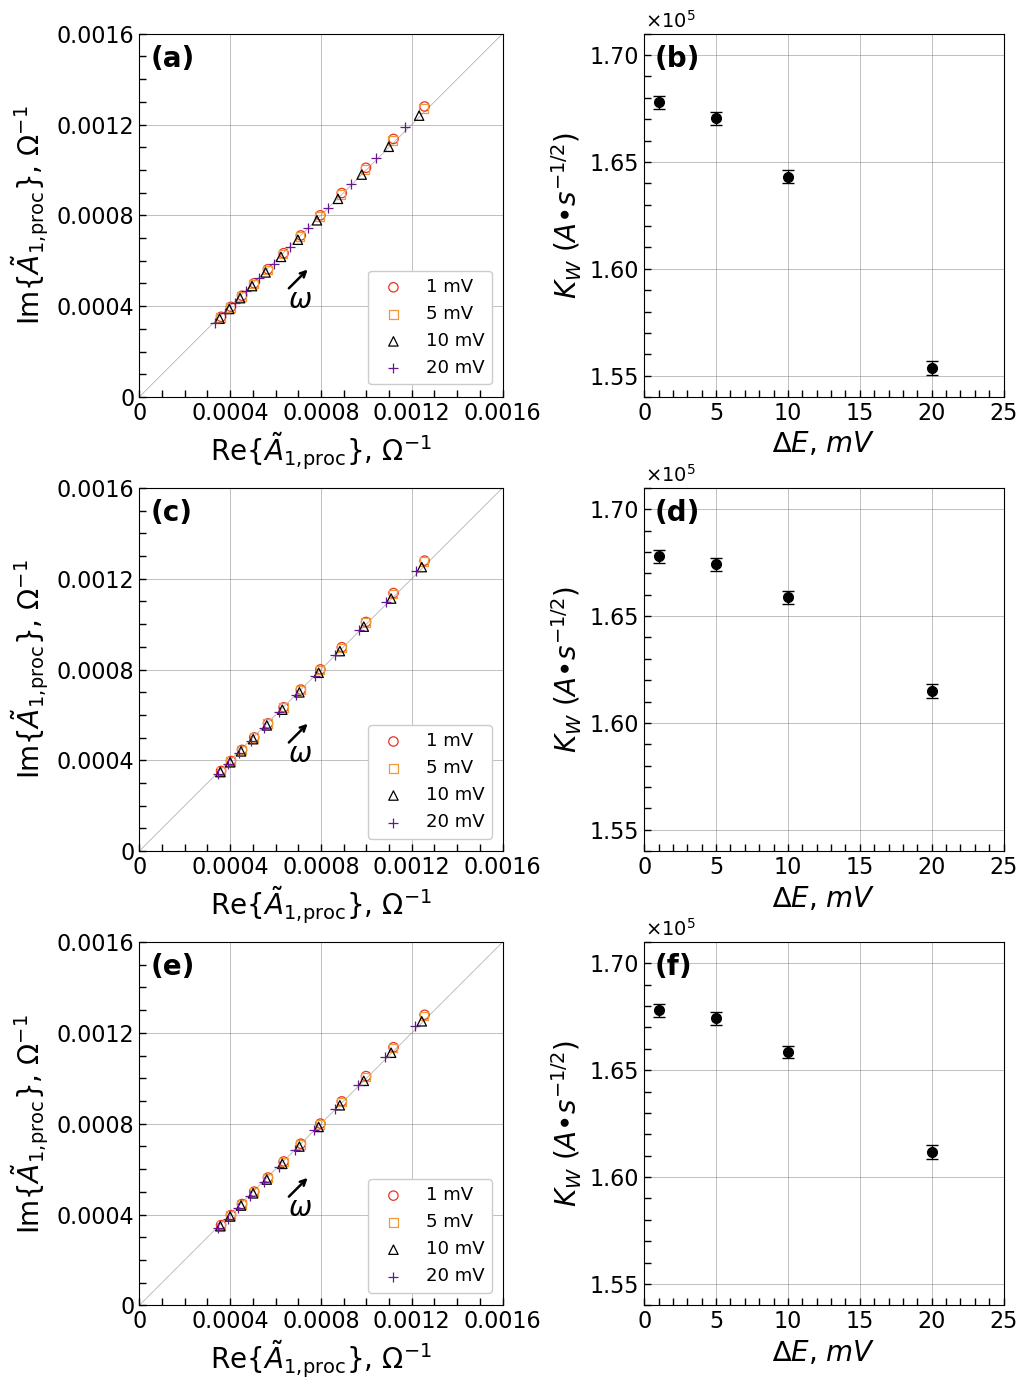

Run 2


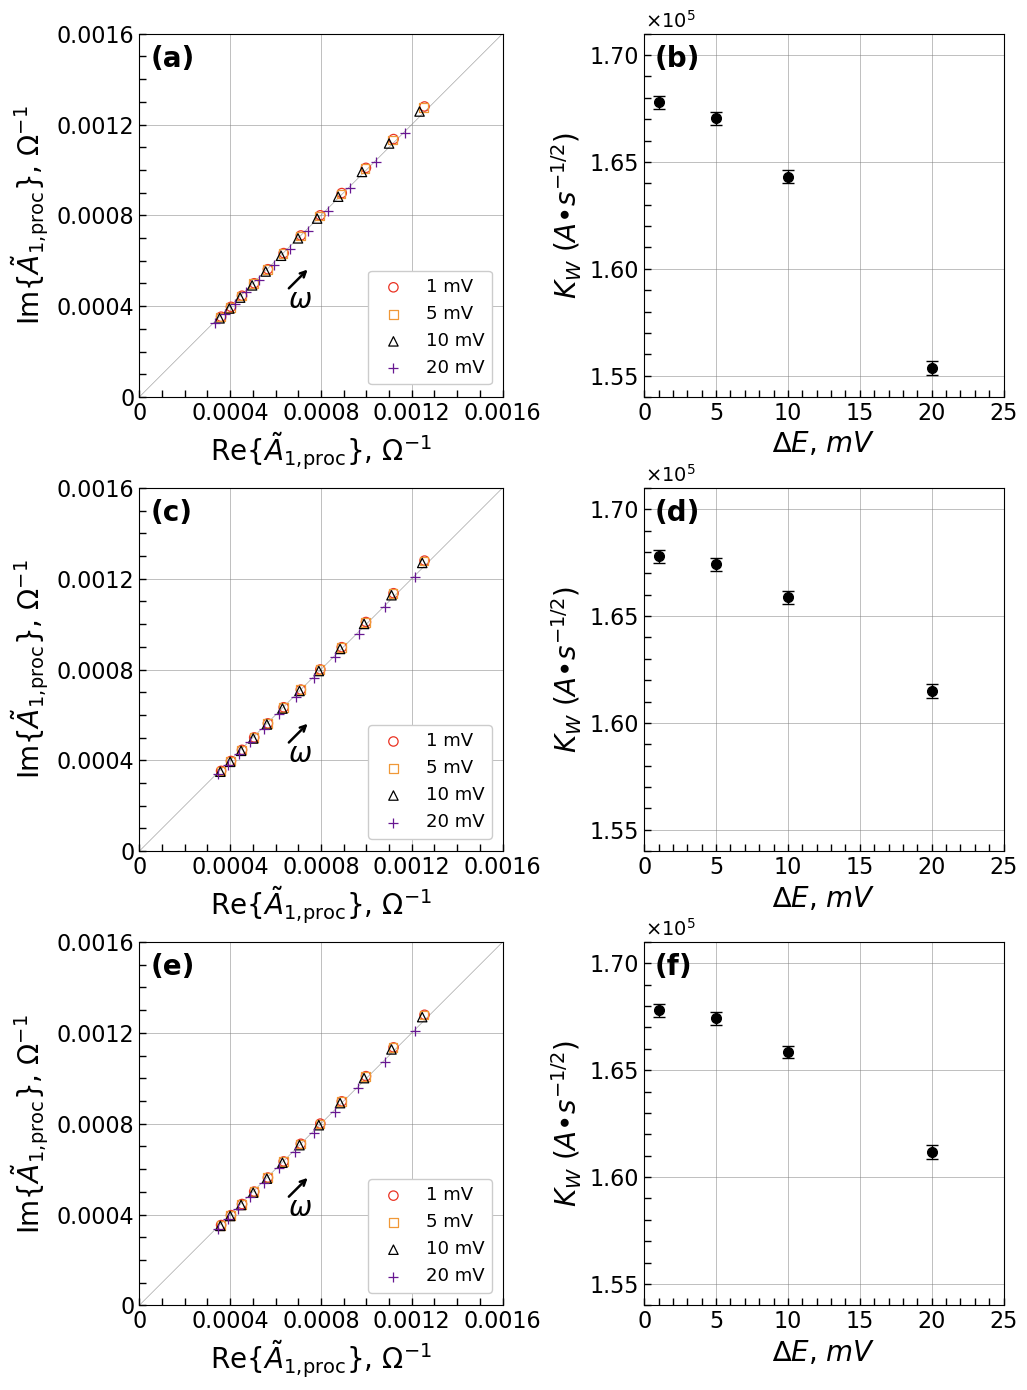

In [127]:

#For Run 1 and Run 2
for run_num in range(1,3):
    
    #Create Figure
    fig, axs = plt.subplots(
        nrows=3, ncols=2, figsize=(10.5, 14),
        gridspec_kw={'width_ratios': [1.8,1]},
        constrained_layout=True
    )
    #Generate Run File Data
    df_t = df[df["File Number"] == run_num]

    #A1 Admittance Subplots (a), (c), (e)
    for i,idx in enumerate(range(3)):  # You have 6 subplots
        ax = axs[idx][0]
        harmonic_j = 1
        x_min = 0
        x_max = 0.0016
        y_min = 0
        y_max = 0.0016
        arrow_start = 0.00065
        arrow_end = 0.00075
        offset = -0.00018  # small offset below the 45-line
        subplot_label = subplot_labels[i]

        # Plot Admittance
        plot_corrected_admittance(ax, orders[i],labels, markers, colors, sizes,
                                df_t, harmonic_j,
                                x_min, x_max, y_min, y_max,
                                arrow_start, arrow_end, offset,subplot_label,r"{\Omega}^{-1}")
    #Kw Fit Subplots (b), (d), (f)
    for i,idx in enumerate(range(3)):
        ax = axs[idx][1]
        subplot_label = subplot_labels[i+3]
        plot_parameter_spectrum(ax,kw_fit_dicts[i],harmonic_j=1,error_mult=1.96,x_min = 0,x_max = 25,y_min=1.54,y_max=1.71,subplot_label=subplot_label)
    
    #Show/Save Figures    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0.25)
    if run_num == 1:
        plt.savefig(f"Figure5_A1_Plot_Run{run_num}.png",dpi=500, bbox_inches='tight', pad_inches=0.1)
    else:
        plt.savefig(f"S7_A1_Plot_Run{run_num}.png",dpi=500, bbox_inches='tight', pad_inches=0.1)
    print(f"Run {run_num}")
    plt.show()



### A2

/var/folders/6l/z6x890s133g488rww9gwhhrc0000gn/T/ipykernel_7777/4055536837.py:96: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Run 1


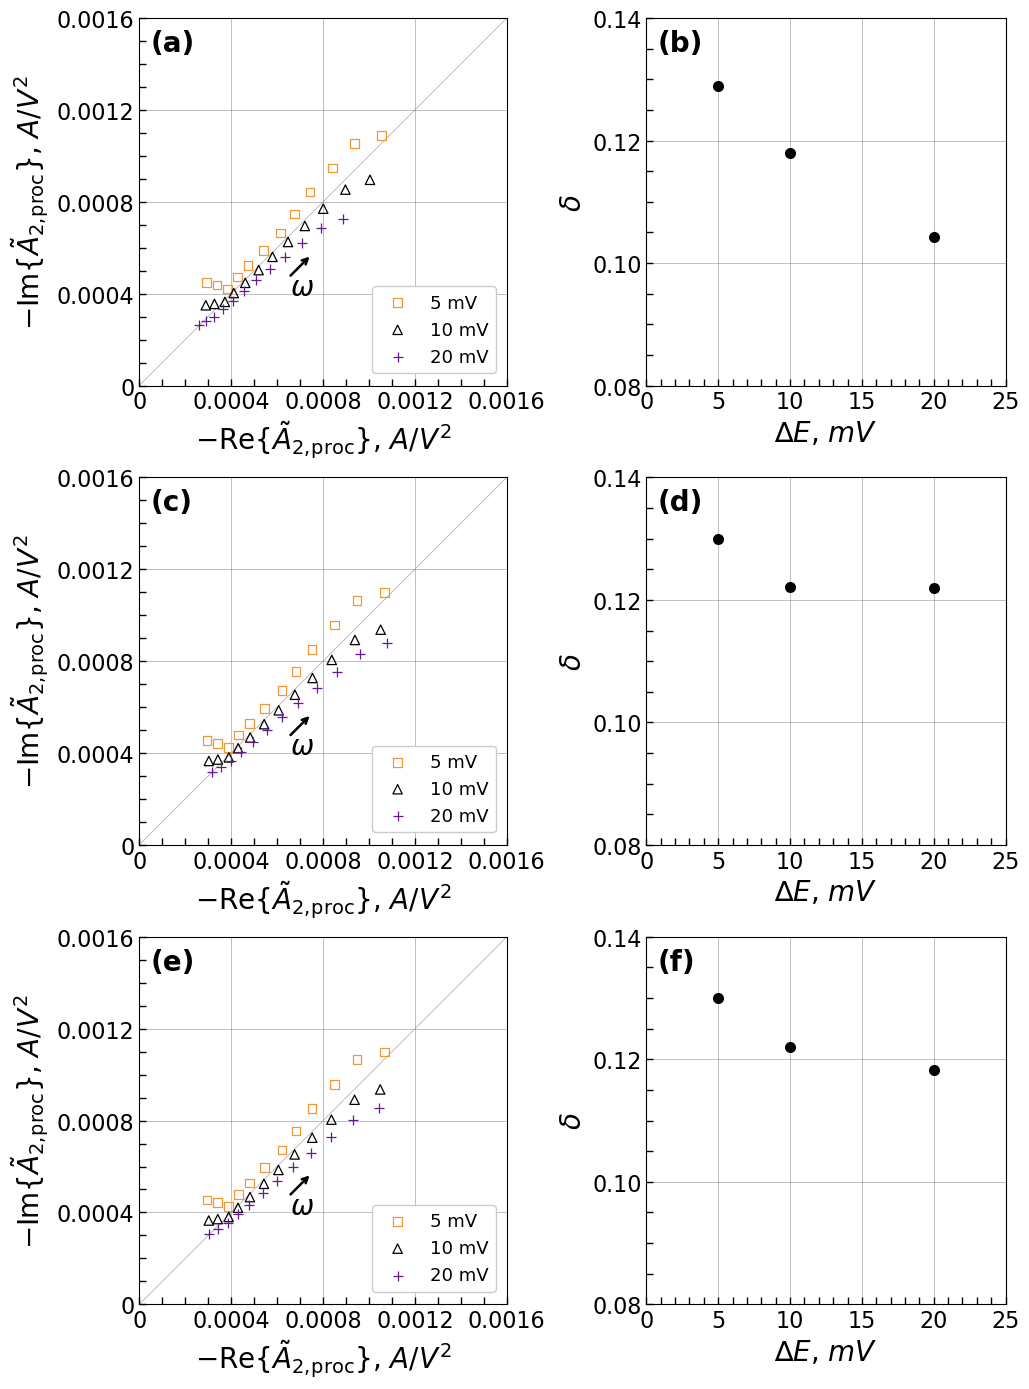

Run 2


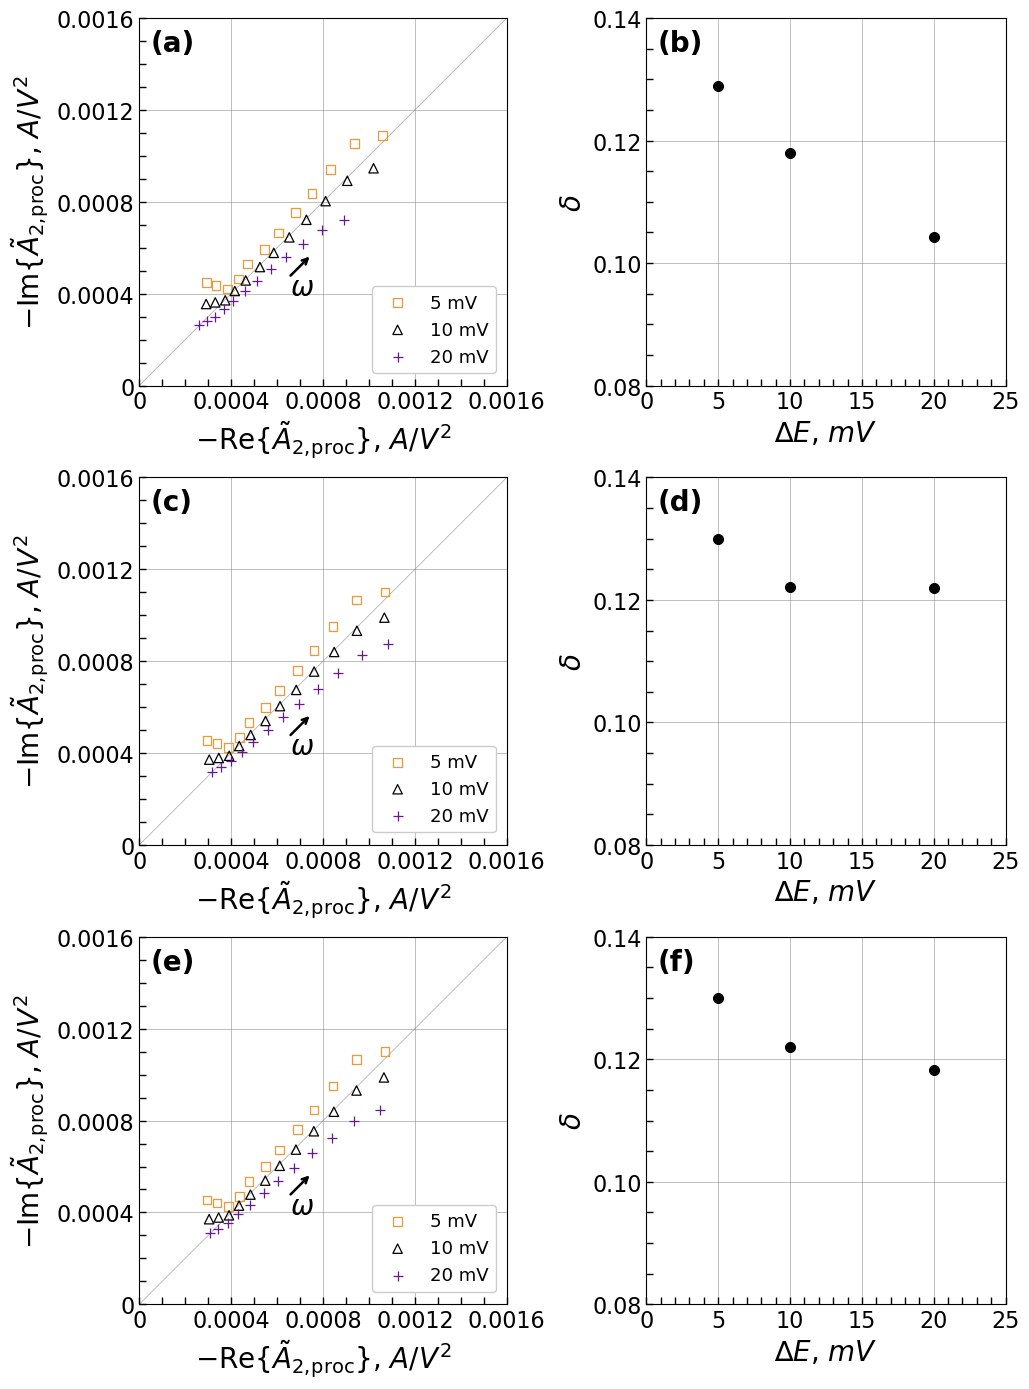

In [128]:

for run_num in range(1,3):
    
    #Create Figure
    fig, axs = plt.subplots(
        nrows=3, ncols=2, figsize=(10.5, 14),
        gridspec_kw={'width_ratios': [1.8,1]},
        constrained_layout=True
    )
    #Generate Run File Data
    df_t = df[df["File Number"] == run_num]

    #A2 Admittance Subplots (a), (c), (e)
    for i,idx in enumerate(range(3)):
        ax = axs[idx][0]
        harmonic_j = 2
        x_min = 0
        x_max = 0.0016
        y_min = 0
        y_max = 0.0016
        arrow_start = 0.00065
        arrow_end = 0.00075
        offset = -0.00018  # small offset below the 45-line
        subplot_label = subplot_labels[i]

        #Plot Admittance
        plot_corrected_admittance(ax, orders[i],labels, markers, colors, sizes,
                                df_t, harmonic_j,
                                x_min, x_max, y_min, y_max,
                                arrow_start, arrow_end, offset,subplot_label,r"{A/V^{2}}")
    #Delta Fit Subplots (b), (d), (f)
    for i,idx in enumerate(range(3)):  # You have 6 subplots
        ax = axs[idx][1]
        subplot_label = subplot_labels[i+3]
        plot_parameter_spectrum(ax,d_fit_dicts[i],harmonic_j=2,error_mult=1,x_min =0,x_max = 25,y_min=0.08,y_max=0.14,subplot_label=subplot_label)
    
    #Show/Save Figures    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0.25)
    if run_num == 1:
        plt.savefig(f"Figure6_A2_Plot_Run{run_num}.png",dpi=500, bbox_inches='tight', pad_inches=0.1)
    else:
        plt.savefig(f"S8_A2_Plot_Run{run_num}.png",dpi=500, bbox_inches='tight', pad_inches=0.1)
    print(f"Run {run_num}")
    plt.show()


### 5. Calculating Diffusion Coefficients

In [116]:
F = 96485 #C/mol
A = ((3*10**(-3))/2)**2*math.pi #m^2
C = (50*10**(-3)*800*10**(-6)) / ((20*10**(-3)+800*10**(-6)) * 0.001) #mol/m3
R = 8.314 #J/mol-K
T = 298 #K
kw_fits = {"2nd":kw_fit_2nd,"4th":kw_fit_4th,"6th":kw_fit_6th}
d_fits = {"2nd":d_fit_2nd,"4th":d_fit_4th,"6th":d_fit_6th}
D_vals = {}
for order in kw_fits:
    kw_dict = kw_fits[order]
    delta_dict = d_fits[order]
    temp_dict = {}
    for mod in kw_dict:
        if mod == "1mV":
            continue
        else:
            kw = kw_dict[mod]["Fit"]
            kw_err = kw_dict[mod]["Error"]
            delta = delta_dict[mod]["Fit"]
            delta_err = delta_dict[mod]["Error"]
            
            D0 = (kw * 2 / (F*A*C))**2 * 10000 #cm2/s
            D0_err = 2 * D0 * kw_err / kw     # propagated error = 4 / (FAC)^2 * Kw^2 * kw_error * 10000 = D0 / 

            DII = D0 * (1-delta) #cm2/s
            DII_err = math.sqrt( (D0_err * (1 - delta))**2 + (D0 * delta_err)**2 )
            
            DIII = D0 * (1+delta) #cm2/s
            DIII_err = math.sqrt( (D0_err * (1 + delta))**2 + (D0 * delta_err)**2 )
            
            temp_dict[mod] = {"D0":{"Fit":D0,"Error":D0_err},
                            "DII":{"Fit":DII,"Error":DII_err},
                            "DIII":{"Fit":DIII,"Error":DIII_err}}
    D_vals[order] = temp_dict

In [117]:
def round_to_error(val, err):
    if err == 0:
        return val, 0
    order = int(np.floor(np.log10(abs(err))))
    rounded_err = round(err, -order)
    rounded_val = round(val, -order)
    return rounded_val, rounded_err

#10 mV Diffusion Values
D_2nd = D_vals["2nd"]["10mV"]
D_4th = D_vals["4th"]["10mV"]
D_6th = D_vals["6th"]["10mV"]
D_dicts = [D_2nd, D_4th, D_6th]
models = ["2nd Order", "4th Order", "6th Order"]

#Calculating the Errors
rows = []
for model, d in zip(models, D_dicts):
    # Convert to 10^6 cm^2/s
    D0_val = d['D0']['Fit'] * 1e6
    D0_err = d['D0']['Error'] * 1e6
    DII_val = d['DII']['Fit'] * 1e6
    DII_err = d['DII']['Error'] * 1e6
    DIII_val = d['DIII']['Fit'] * 1e6
    DIII_err = d['DIII']['Error'] * 1e6
    
    # Round to first significant digit of error
    D0_val_r, D0_err_r = round_to_error(D0_val, D0_err)
    DII_val_r, DII_err_r = round_to_error(DII_val, DII_err)
    DIII_val_r, DIII_err_r = round_to_error(DIII_val, DIII_err)
    
    # Format as "value ± error"
    D0_str = f"{D0_val_r} ± {D0_err_r}"
    DII_str = f"{DII_val_r}"
    DIII_str = f"{DIII_val_r}"
    
    rows.append([model, D0_str, DII_str, DIII_str])

# Create DataFrame
df_table = pd.DataFrame(rows, columns=[
    "Model", r"D^0 (10^-6 cm^2/s)",
    r"D^II (10^-6 cm^2/s))",
    r"D^III (10^-6 cm^2/s))"
])
df_table


,Model,D^0 (10^-6 cm^2/s),D^II (10^-6 cm^2/s)),D^III (10^-6 cm^2/s))
0,2nd Order,6.28 ± 0.01,5.54,7.02
1,4th Order,6.4 ± 0.01,5.62,7.18
2,6th Order,6.4 ± 0.01,5.62,7.18
